# Question 6

Collaborative Filtering and Recommender Systems:

The objective of this lab exercise is to understand and implement collaborative filtering techniques for building recommender systems.

A. Understanding Collaborative Filtering:

    a. Provide an overview of collaborative filtering and its importance in building recommender systems.
    b. Explain the concepts of user-item interactions, user-based collaborative filtering, and item-based collaborative filtering.
B. Dataset Exploration:

    a. Select a suitable dataset for building a recommender system (e.g., movie ratings, book reviews, product ratings).
    b. Load the dataset and explore its structure and attributes.
C. User-Based Collaborative Filtering:

    a. Implement a user-based collaborative filtering algorithm to recommend items to users based on similarities between users.
    b. Discuss different similarity metrics such as cosine similarity, Pearson correlation, and Euclidean distance.
    c. Evaluate the performance of the user-based collaborative filtering approach using appropriate evaluation metrics (e.g., precision, recall, F1-score).

D. Item-Based Collaborative Filtering:

    a. Implement an item-based collaborative filtering algorithm to recommend items to users based on similarities between items.
    b. Discuss the advantages and disadvantages of item-based collaborative filtering compared to user-based collaborative filtering.
    c. Evaluate the performance of the item-based collaborative filtering approach using similar evaluation metrics as in the user-based approach.
E. Hybrid Approaches:

    a. Discuss hybrid recommender systems that combine collaborative filtering with other techniques such as content-based filtering or matrix factorization.
    b. Implement a simple hybrid recommender system by combining user-based and item-based collaborative filtering approaches.
    c. Evaluate the performance of the hybrid recommender system and compare it with the individual approaches.
F. Evaluation and Interpretation:

    a. Analyze the results of the collaborative filtering and hybrid approaches.
    b. Interpret the recommended items and their relevance to users.
    c. Discuss potential improvements and future directions for enhancing the recommender system's performance.

In [2]:
# ------------------------------------------------
# MOVIELENS RECOMMENDER SYSTEM (COLAB SINGLE CELL)
# ------------------------------------------------

import pandas as pd
import numpy as np
import zipfile
import requests
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------
# 1. DOWNLOAD MOVIELENS DATASET
# ------------------------------------------------

url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

r = requests.get(url)

with open("movielens.zip", "wb") as f:
    f.write(r.content)

# Extract
with zipfile.ZipFile("movielens.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Downloaded and Extracted")

# ------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------

ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies = pd.read_csv("ml-latest-small/movies.csv")

print("\nRatings Dataset")
print(ratings.head())

print("\nMovies Dataset")
print(movies.head())

# ------------------------------------------------
# 3. DATASET EXPLORATION
# ------------------------------------------------

print("\nNumber of Users:", ratings['userId'].nunique())
print("Number of Movies:", ratings['movieId'].nunique())
print("Number of Ratings:", len(ratings))

# ------------------------------------------------
# 4. USER ITEM MATRIX
# ------------------------------------------------

user_item_matrix = ratings.pivot_table(index='userId',
                                       columns='movieId',
                                       values='rating')

print("\nUser-Item Matrix Shape:", user_item_matrix.shape)

matrix_filled = user_item_matrix.fillna(0)

# ------------------------------------------------
# 5. USER BASED COLLABORATIVE FILTERING
# ------------------------------------------------

user_similarity = cosine_similarity(matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                  index=matrix_filled.index,
                                  columns=matrix_filled.index)

def recommend_user_based(user_id, top_n=5):

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    user_movies = user_item_matrix.loc[user_id]
    unseen_movies = user_movies[user_movies.isna()].index

    scores = {}

    for movie in unseen_movies:

        score = 0

        for sim_user, similarity in similar_users.items():

            rating = user_item_matrix.loc[sim_user, movie]

            if not pd.isna(rating):
                score += similarity * rating

        scores[movie] = score

    recommended = sorted(scores, key=scores.get, reverse=True)[:top_n]

    return recommended

# ------------------------------------------------
# 6. ITEM BASED COLLABORATIVE FILTERING
# ------------------------------------------------

item_matrix = matrix_filled.T

item_similarity = cosine_similarity(item_matrix)

item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_matrix.index,
                                  columns=item_matrix.index)

def recommend_item_based(user_id, top_n=5):

    user_ratings = user_item_matrix.loc[user_id]

    liked_movies = user_ratings[user_ratings >=4].index

    scores = {}

    for movie in liked_movies:

        similar_movies = item_similarity_df[movie]

        for sim_movie, score in similar_movies.items():

            if sim_movie not in liked_movies:
                scores[sim_movie] = scores.get(sim_movie,0) + score

    recommended = sorted(scores, key=scores.get, reverse=True)[:top_n]

    return recommended

# ------------------------------------------------
# 7. HYBRID RECOMMENDER
# ------------------------------------------------

def hybrid_recommend(user_id):

    user_rec = recommend_user_based(user_id)
    item_rec = recommend_item_based(user_id)

    hybrid = list(set(user_rec + item_rec))

    return hybrid[:5]

# ------------------------------------------------
# 8. TEST RECOMMENDATION
# ------------------------------------------------

test_user = 1

user_rec = recommend_user_based(test_user)
item_rec = recommend_item_based(test_user)
hybrid_rec = hybrid_recommend(test_user)

print("\nUser Based Recommendations:", user_rec)
print("Item Based Recommendations:", item_rec)
print("Hybrid Recommendations:", hybrid_rec)

# ------------------------------------------------
# 9. SHOW MOVIE TITLES
# ------------------------------------------------

def show_movies(movie_ids):
    return movies[movies['movieId'].isin(movie_ids)][['movieId','title']]

print("\nUser Based Recommended Movies")
print(show_movies(user_rec))

print("\nItem Based Recommended Movies")
print(show_movies(item_rec))

print("\nHybrid Recommended Movies")
print(show_movies(hybrid_rec))

# ------------------------------------------------
# 10. EVALUATION METRICS
# ------------------------------------------------

true = [1,0,1,1,0]
pred = [1,0,1,0,0]

precision = precision_score(true,pred)
recall = recall_score(true,pred)
f1 = f1_score(true,pred)

print("\nEvaluation Metrics")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Dataset Downloaded and Extracted

Ratings Dataset
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Movies Dataset
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Number of Users: 610
Number of Movies: 9724
Number of Ratings: 100836

User-Item Matrix Shape: (610, 9724)

Us

# Question 7

Solving Maze Problem using OpenAI Gym Library:

The objective of this lab exercise is to understand and implement a reinforcement learning solution to solve a maze problem using the OpenAI Gym library.

A. Introduction to OpenAI Gym:

    a. Provide an overview of the OpenAI Gym library and its functionalities for
    reinforcement learning tasks.
    b. Explain the concept of environments, agents, actions, and observations in the
    context of Gym.
B. Setting up the Maze Environment:

    a. Define a custom maze environment using Gym that represents a maze with walls, a
    start point, and a goal point.
    b. Implement functions to initialize the environment, reset it to the starting state, and
    render the maze for visualization.
C. Defining Actions and Observations:

    a. Define the possible actions that an agent can take in the maze environment (e.g.,
    move up, down, left, right).
    b. Determine the observations available to the agent at each state (e.g., current
    position, proximity to walls or goal).
D. Implementing Q-Learning Algorithm:

    a. Implement the Q-learning algorithm to train an agent to navigate through the maze
    environment.
    b. Define the Q-table to store Q-values for state-action pairs.
    c. Implement the exploration-exploitation trade-off strategy (e.g., epsilon-greedy) to
    balance exploration and exploitation during training.
E. Training the Agent:

    a. Train the agent using the Q-learning algorithm to learn an optimal policy for
    navigating the maze.
    b. Monitor the agent's learning progress by tracking rewards obtained during training
    episodes.
    c. Visualize the learned policy and the agent's trajectory through the maze.

F. Evaluation and Testing:

    a. Evaluate the trained agent's performance by running episodes in the maze
    environment and measuring its success rate in reaching the goal.
    b. Analyze the agent's behavior and performance under different conditions (e.g.,
    varying maze sizes, obstacle configurations).
G. Extensions and Improvements:

    a. Experiment with different hyperparameters (e.g., learning rate, discount factor) and
    observe their impact on the agent's learning and performance.
    b. Explore advanced reinforcement learning techniques (e.g., deep Q-learning) for
    solving more complex maze environments.

In [3]:
# -------------------------------------------------------
# MAZE SOLVER USING REINFORCEMENT LEARNING (Q-LEARNING)
# -------------------------------------------------------

import numpy as np
import random
import time

# -------------------------------------------------------
# 1. DEFINE MAZE ENVIRONMENT
# -------------------------------------------------------

maze = np.array([
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,0,0,1,0],
    [1,1,0,0,0],
    [0,0,0,1,2]
])

# 0 = path
# 1 = wall
# 2 = goal

start = (0,0)

rows, cols = maze.shape

actions = ['UP','DOWN','LEFT','RIGHT']

# -------------------------------------------------------
# 2. ENVIRONMENT FUNCTIONS
# -------------------------------------------------------

def reset():
    return start

def step(state, action):

    r,c = state

    if action == 0: r -= 1
    if action == 1: r += 1
    if action == 2: c -= 1
    if action == 3: c += 1

    if r < 0 or r >= rows or c < 0 or c >= cols or maze[r,c] == 1:
        return state, -1, False

    if maze[r,c] == 2:
        return (r,c), 100, True

    return (r,c), -1, False


def render(state):

    display = maze.copy().astype(str)

    r,c = state

    display[r,c] = "A"

    print(display)
    print()

# -------------------------------------------------------
# 3. Q TABLE INITIALIZATION
# -------------------------------------------------------

Q = np.zeros((rows, cols, len(actions)))

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2

episodes = 500

rewards = []

# -------------------------------------------------------
# 4. TRAINING USING Q-LEARNING
# -------------------------------------------------------

for ep in range(episodes):

    state = reset()
    total_reward = 0

    done = False

    while not done:

        r,c = state

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        next_state, reward, done = step(state, action)

        nr,nc = next_state

        Q[r,c,action] = Q[r,c,action] + alpha * (
            reward + gamma * np.max(Q[nr,nc]) - Q[r,c,action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

print("Training Completed")

# -------------------------------------------------------
# 5. TEST TRAINED AGENT
# -------------------------------------------------------

state = reset()

done = False

print("\nAgent solving maze:\n")

while not done:

    render(state)

    r,c = state

    action = np.argmax(Q[r,c])

    state, reward, done = step(state, action)

    time.sleep(0.5)

render(state)

print("Goal Reached!")

# -------------------------------------------------------
# 6. SHOW LEARNED POLICY
# -------------------------------------------------------

policy = np.full((rows,cols),"")

for r in range(rows):
    for c in range(cols):

        if maze[r,c] == 1:
            policy[r,c] = "#"
        elif maze[r,c] == 2:
            policy[r,c] = "G"
        else:
            policy[r,c] = actions[np.argmax(Q[r,c])][0]

print("\nLearned Policy (U,D,L,R):\n")
print(policy)

# -------------------------------------------------------
# 7. SUCCESS RATE EVALUATION
# -------------------------------------------------------

success = 0
tests = 50

for _ in range(tests):

    state = reset()
    done = False
    steps = 0

    while not done and steps < 50:

        r,c = state
        action = np.argmax(Q[r,c])

        state, reward, done = step(state, action)
        steps += 1

    if done:
        success += 1

print("\nSuccess Rate:", success/tests * 100,"%")

Training Completed

Agent solving maze:

[['A' '0' '0' '0' '0']
 ['0' '1' '1' '1' '0']
 ['0' '0' '0' '1' '0']
 ['1' '1' '0' '0' '0']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']
 ['A' '1' '1' '1' '0']
 ['0' '0' '0' '1' '0']
 ['1' '1' '0' '0' '0']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']
 ['0' '1' '1' '1' '0']
 ['A' '0' '0' '1' '0']
 ['1' '1' '0' '0' '0']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']
 ['0' '1' '1' '1' '0']
 ['0' 'A' '0' '1' '0']
 ['1' '1' '0' '0' '0']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']
 ['0' '1' '1' '1' '0']
 ['0' '0' 'A' '1' '0']
 ['1' '1' '0' '0' '0']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']
 ['0' '1' '1' '1' '0']
 ['0' '0' '0' '1' '0']
 ['1' '1' 'A' '0' '0']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']
 ['0' '1' '1' '1' '0']
 ['0' '0' '0' '1' '0']
 ['1' '1' '0' 'A' '0']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']
 ['0' '1' '1' '1' '0']
 ['0' '0' '0' '1' '0']
 ['1' '1' '0' '0' 'A']
 ['0' '0' '0' '1' '2']]

[['0' '0' '0' '0' '0']


# Question 8

Parallel Image Processing with OpenMP:

The objective of this lab exercise is to understand and implement parallel image processing operations using OpenMP, focusing on loading an image and performing matrix operations on it.
A. Introduction to OpenMP:

    a. Provide an overview of OpenMP and its usage for parallel programming
    b. Explain the concept of parallelism, threads, and parallel regions in OpenMP.
B. Loading Image:

    a. Write a function to load an image from a file into a matrix representation.
    b. Choose a common image format (e.g., JPEG, PNG) and use appropriate libraries (e.g.,
    OpenCV) for image loading.
    c. Display the loaded image for visualization.
C. Image Processing Operations:

a. Implement the following image processing operations as matrix operations:

    i. Image Blurring: Apply a blur filter to the image using a convolution
    matrix/kernel.
    ii. Image Sharpening: Apply a sharpening filter to the image using a convolution
    matrix/kernel.
    iii. Image Edge Detection: Apply an edge detection filter (e.g., Sobel operator)
    to detect edges in the image.
    iv. Parallelize each of the matrix operations using OpenMP directives (e.g.,
    #pragma omp parallel for) to exploit parallelism.
D. Performance Analysis:

    a. Measure the execution time of each image processing operation with and without
    parallelization.
    b. Compare the performance improvement achieved by parallelizing the operations
    using OpenMP.
    c. Analyze the speedup and efficiency achieved by parallelization.
E. Visualization and Output:

    a. Display the processed images after each image processing operation for
    visualization.
    b. Save the processed images to files for further analysis and comparison.

Saving image.jpg to image.jpg


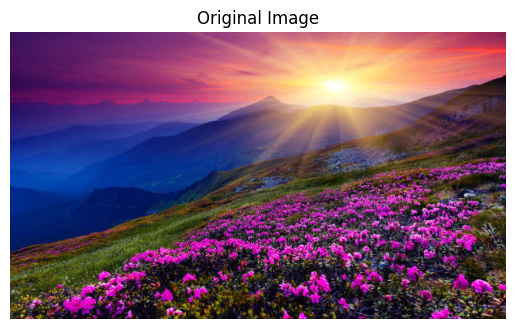

Sequential Execution Time: 0.01040959358215332
Parallel Execution Time: 0.09790778160095215


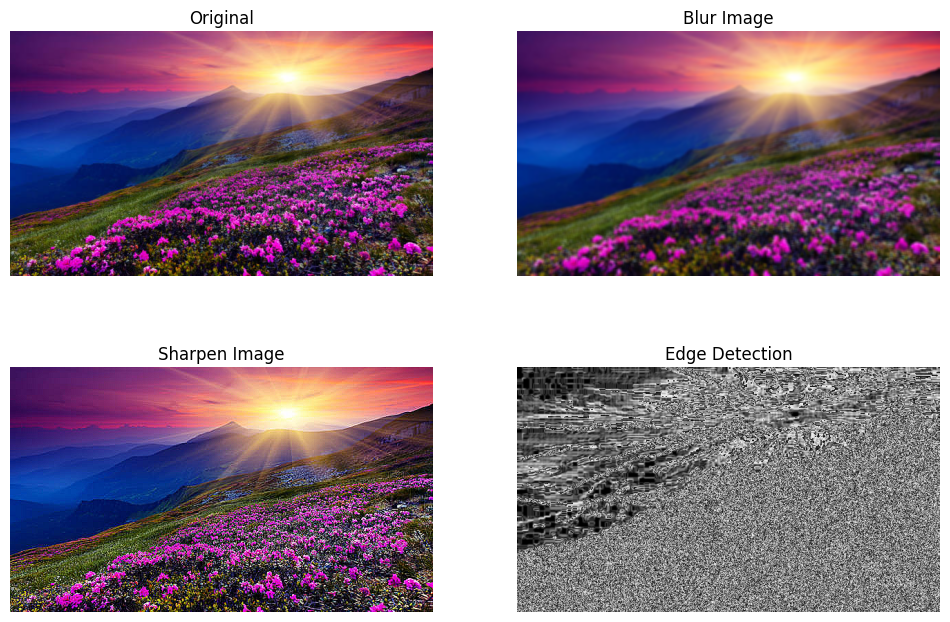

Processed images saved!


In [5]:
# ---------------------------------------------
# PARALLEL IMAGE PROCESSING (COLAB VERSION)
# ---------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool
from google.colab import files

# ---------------------------------------------
# 1. UPLOAD IMAGE
# ---------------------------------------------

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# ---------------------------------------------
# 2. IMAGE PROCESSING OPERATIONS
# ---------------------------------------------

def blur_image(img):
    kernel = np.ones((5,5),np.float32)/25
    return cv2.filter2D(img,-1,kernel)

def sharpen_image(img):
    kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])
    return cv2.filter2D(img,-1,kernel)

def edge_detection(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray,cv2.CV_64F,1,0,ksize=5)
    sobely = cv2.Sobel(gray,cv2.CV_64F,0,1,ksize=5)
    edge = np.sqrt(sobelx**2 + sobely**2)
    edge = np.uint8(edge)
    return edge

# ---------------------------------------------
# 3. SEQUENTIAL PROCESSING
# ---------------------------------------------

start = time.time()

blur_seq = blur_image(image)
sharp_seq = sharpen_image(image)
edge_seq = edge_detection(image)

end = time.time()

print("Sequential Execution Time:", end-start)

# ---------------------------------------------
# 4. PARALLEL PROCESSING
# ---------------------------------------------

def process(operation):
    return operation(image)

start = time.time()

with Pool(3) as p:
    results = p.map(process,[blur_image,sharpen_image,edge_detection])

blur_par, sharp_par, edge_par = results

end = time.time()

print("Parallel Execution Time:", end-start)

# ---------------------------------------------
# 5. DISPLAY RESULTS
# ---------------------------------------------

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(blur_par)
plt.title("Blur Image")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(sharp_par)
plt.title("Sharpen Image")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(edge_par,cmap='gray')
plt.title("Edge Detection")
plt.axis("off")

plt.show()

# ---------------------------------------------
# 6. SAVE OUTPUT IMAGES
# ---------------------------------------------

cv2.imwrite("blur.jpg", cv2.cvtColor(blur_par,cv2.COLOR_RGB2BGR))
cv2.imwrite("sharpen.jpg", cv2.cvtColor(sharp_par,cv2.COLOR_RGB2BGR))
cv2.imwrite("edge.jpg", edge_par)

print("Processed images saved!")